### How2Sign — re-aligned annotations + frontal keypoints

- **Annotations:** `data/annotations/how2sign_realigned_*.csv` (tab-separated). **Use the same split as your keypoints** (e.g. test CSV with `data/test/frontal`, val CSV with `data/val/frontal`).
- **Keypoints:** any `data/**/frontal/*.npy` — stem matches `SENTENCE_NAME` or `SENTENCE_ID`, or `*_holistic` for raw dumps.

The plot cell searches **all** `data/**/frontal` folders. If nothing matches the CSV, it plots the first `.npy` it finds and prints a warning (or set `MANUAL_NPY_PATH` in that cell).

Run: load CSV → overlap stats → plot.

Auto-found: data/--7E2sU6zP4_10-5-rgb_front.npy
Loaded: --7E2sU6zP4_10-5-rgb_front.npy  shape=(365, 543, 3)
Frames: 365
Selected: (365, 75, 3) → flattened: (365, 225)


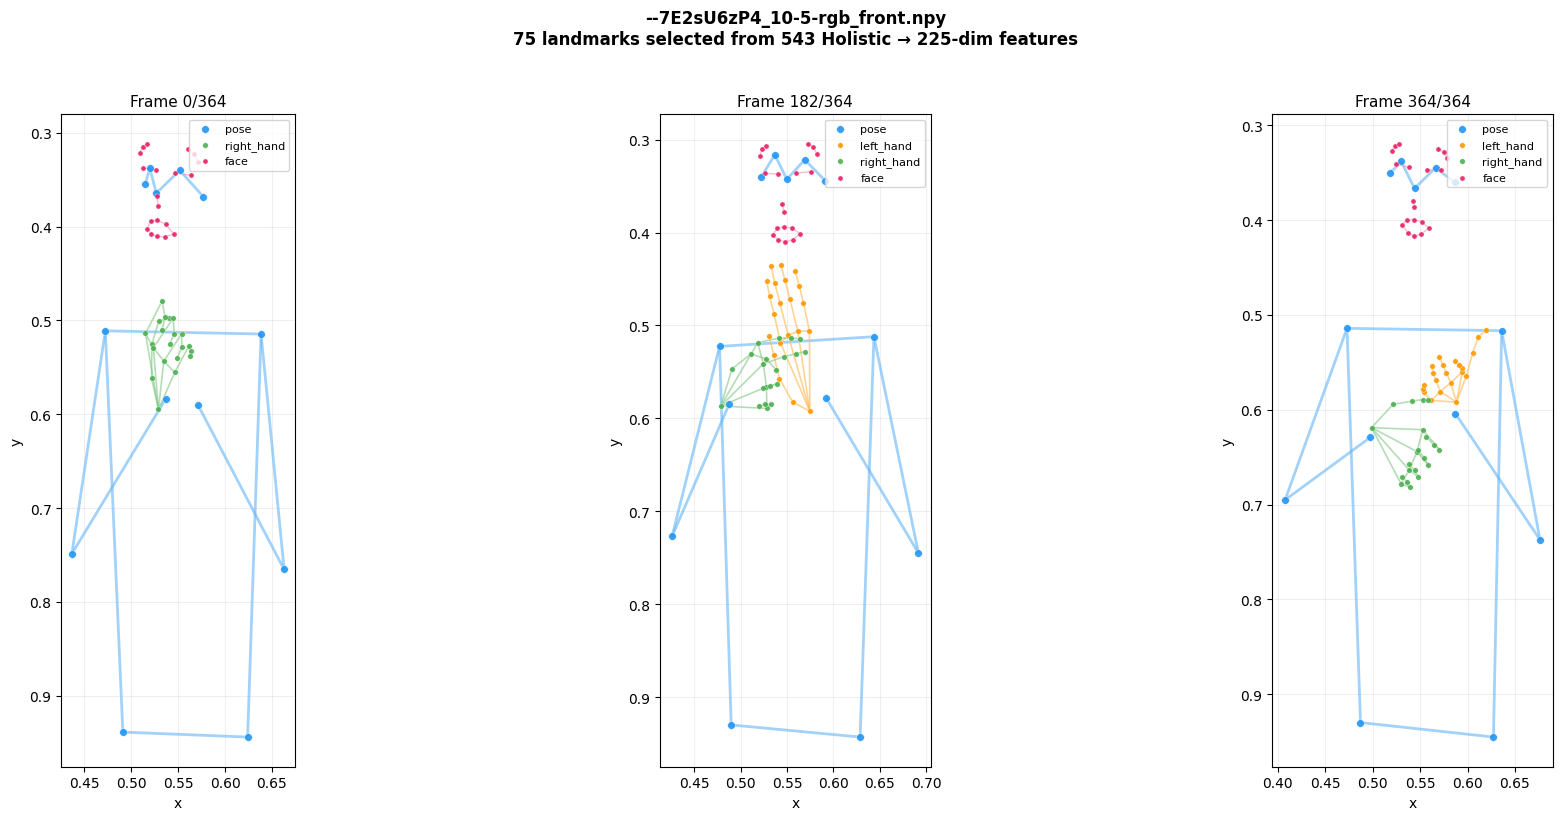

Saved: skeleton_75_from_543.png


In [4]:
"""
Visualize 75 selected landmarks from How2Sign (T, 543, 3) Holistic keypoints.

Selects the same 75 landmarks used in the PHOENIX pipeline:
  13 pose + 21 left hand + 21 right hand + 20 face = 75 joints × 3 coords = 225 features

Draws skeleton connections using matplotlib lines (cleaner than OpenCV for normalized coords).
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from pathlib import Path

# ─── Landmark selection from 543 Holistic ───────────────────────────
# MediaPipe Holistic layout:
#   Pose:       0 - 32    (33 landmarks)
#   Face:      33 - 500   (468 landmarks)  →  face mesh idx i = holistic idx 33+i
#   Left hand: 501 - 521  (21 landmarks)
#   Right hand:522 - 542  (21 landmarks)

# 13 upper-body pose landmarks (holistic indices)
POSE_SELECT = [0, 2, 5, 7, 8, 11, 12, 13, 14, 15, 16, 23, 24]

# 21 hand landmarks each (holistic indices)
LHAND_SELECT = list(range(501, 522))
RHAND_SELECT = list(range(522, 543))

# 20 face landmarks — face mesh indices mapped to holistic space (33 + mesh_idx)
FACE_MESH_IDS = [
    61, 291, 0, 17, 39, 269, 181, 405,   # lips (8)
    70, 63, 105,                           # left eyebrow (3)
    300, 293, 334,                         # right eyebrow (3)
    33, 133,                               # left eye (2)
    263, 362,                              # right eye (2)
    1, 2,                                  # nose (2)
]
FACE_SELECT = [33 + i for i in FACE_MESH_IDS]

# Combined: 13 + 21 + 21 + 20 = 75
ALL_SELECT = np.array(POSE_SELECT + LHAND_SELECT + RHAND_SELECT + FACE_SELECT)
assert len(ALL_SELECT) == 75, f"Expected 75, got {len(ALL_SELECT)}"

# ─── Group boundaries in the 75-joint array ─────────────────────────
P = len(POSE_SELECT)        # 13
LH = len(LHAND_SELECT)      # 21
RH = len(RHAND_SELECT)      # 21
F = len(FACE_MESH_IDS)      # 20

POSE_RANGE  = (0, P)                              # 0..12
LHAND_RANGE = (P, P + LH)                         # 13..33
RHAND_RANGE = (P + LH, P + LH + RH)               # 34..54
FACE_RANGE  = (P + LH + RH, P + LH + RH + F)      # 55..74

# ─── Skeleton connections (indices into the 75-joint array) ──────────

# Pose connections (indices 0-12 map to selected pose landmarks)
# Selected pose: [nose, l_eye, r_eye, l_ear, r_ear, l_shoulder, r_shoulder,
#                 l_elbow, r_elbow, l_wrist, r_wrist, l_hip, r_hip]
#  idx:            0      1      2      3      4      5          6
#                  7      8      9      10     11     12
POSE_CONNS = [
    (0, 1), (0, 2), (1, 3), (2, 4),       # nose → eyes → ears
    (5, 6),                                 # shoulder span
    (5, 7), (7, 9),                         # left arm
    (6, 8), (8, 10),                        # right arm
    (5, 11), (6, 12),                       # torso sides
    (11, 12),                               # hip span
]

# Hand connections (MediaPipe 21-point hand topology)
# 0=wrist, 1-4=thumb, 5-8=index, 9-12=middle, 13-16=ring, 17-20=pinky
def _hand_conns(offset):
    conns = []
    # wrist to each finger base
    for base in [1, 5, 9, 13, 17]:
        conns.append((offset, offset + base))
    # each finger chain
    for start in [1, 5, 9, 13, 17]:
        for i in range(3):
            conns.append((offset + start + i, offset + start + i + 1))
    # palm connections
    for a, b in [(5, 9), (9, 13), (13, 17)]:
        conns.append((offset + a, offset + b))
    return conns

LHAND_CONNS = _hand_conns(P)           # offset = 13
RHAND_CONNS = _hand_conns(P + LH)      # offset = 34

# Face connections (indices 55-74 in the 75-joint array)
# Lips: 0-7, L-eyebrow: 8-10, R-eyebrow: 11-13, L-eye: 14-15, R-eye: 16-17, Nose: 18-19
FO = P + LH + RH  # face offset = 55
FACE_CONNS = [
    # Lips outline (approximate loop)
    (FO+0, FO+4), (FO+4, FO+2), (FO+2, FO+5), (FO+5, FO+1),  # upper lip
    (FO+0, FO+6), (FO+6, FO+3), (FO+3, FO+7), (FO+7, FO+1),  # lower lip
    # Eyebrows
    (FO+8, FO+9), (FO+9, FO+10),       # left eyebrow
    (FO+11, FO+12), (FO+12, FO+13),    # right eyebrow
    # Eyes
    (FO+14, FO+15),                     # left eye corners
    (FO+16, FO+17),                     # right eye corners
    # Nose bridge
    (FO+18, FO+19),
]

# ─── Extraction function ────────────────────────────────────────────

def select_75_from_543(data_543: np.ndarray) -> np.ndarray:
    """
    Select 75 landmarks from (T, 543, 3) → (T, 75, 3).
    Flatten to (T, 225) for model input.

    Args:
        data_543: np.ndarray of shape (T, 543, 3)
    Returns:
        np.ndarray of shape (T, 75, 3)
    """
    assert data_543.ndim == 3 and data_543.shape[1] == 543 and data_543.shape[2] == 3, \
        f"Expected (T, 543, 3), got {data_543.shape}"
    return data_543[:, ALL_SELECT, :]   # (T, 75, 3)


def select_and_flatten(data_543: np.ndarray) -> np.ndarray:
    """(T, 543, 3) → (T, 225) ready for model input."""
    selected = select_75_from_543(data_543)
    return selected.reshape(selected.shape[0], -1)


# ─── Plotting ───────────────────────────────────────────────────────

COLORS = {
    "pose":       "#2196F3",   # blue
    "left_hand":  "#FF9800",   # orange
    "right_hand": "#4CAF50",   # green
    "face":       "#E91E63",   # pink
}

CONN_COLORS = {
    "pose":       "#64B5F6",
    "left_hand":  "#FFB74D",
    "right_hand": "#81C784",
    "face":       "#F48FB1",
}


def plot_skeleton(joints_75x3: np.ndarray, title: str = "", ax=None):
    """
    Plot 75 landmarks with skeleton connections.

    Args:
        joints_75x3: (75, 3) array — x, y, z coords (only x, y plotted)
        title: plot title
        ax: optional matplotlib Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 8))
    else:
        fig = ax.figure

    xy = joints_75x3[:, :2]

    # ── Draw connections ──
    def draw_conns(conns, color, lw=1.5, alpha=0.6):
        segments = []
        for i, j in conns:
            # skip if either endpoint is zero (missing detection)
            if np.allclose(xy[i], 0) or np.allclose(xy[j], 0):
                continue
            segments.append([xy[i], xy[j]])
        if segments:
            lc = LineCollection(segments, colors=color, linewidths=lw, alpha=alpha)
            ax.add_collection(lc)

    draw_conns(POSE_CONNS, CONN_COLORS["pose"], lw=2.0)
    draw_conns(LHAND_CONNS, CONN_COLORS["left_hand"], lw=1.2)
    draw_conns(RHAND_CONNS, CONN_COLORS["right_hand"], lw=1.2)
    draw_conns(FACE_CONNS, CONN_COLORS["face"], lw=1.0)

    # ── Draw joints ──
    groups = {
        "pose":       xy[POSE_RANGE[0]:POSE_RANGE[1]],
        "left_hand":  xy[LHAND_RANGE[0]:LHAND_RANGE[1]],
        "right_hand": xy[RHAND_RANGE[0]:RHAND_RANGE[1]],
        "face":       xy[FACE_RANGE[0]:FACE_RANGE[1]],
    }
    sizes = {"pose": 30, "left_hand": 16, "right_hand": 16, "face": 14}

    for name, pts in groups.items():
        # skip zero-valued (missing) points
        mask = ~np.all(pts == 0, axis=1)
        if mask.any():
            ax.scatter(pts[mask, 0], pts[mask, 1],
                       s=sizes[name], c=COLORS[name], label=name,
                       alpha=0.9, zorder=5, edgecolors='white', linewidths=0.3)

    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title, fontsize=11)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.8)
    ax.grid(True, alpha=0.2)

    return fig, ax


# ─── Main: load, select, plot ───────────────────────────────────────

if __name__ == "__main__":
    import sys

    # Accept path as CLI argument or use a default
    npy_path = Path("./data/--7E2sU6zP4_10-5-rgb_front.npy")
    print(f"Auto-found: {npy_path}")

    # Load
    raw = np.load(npy_path)
    print(f"Loaded: {npy_path.name}  shape={raw.shape}")

    # Handle different shapes
    if raw.ndim == 3 and raw.shape[1] == 543 and raw.shape[2] == 3:
        data_543 = raw
    elif raw.ndim == 2 and raw.shape[1] == 543 * 3:
        data_543 = raw.reshape(raw.shape[0], 543, 3)
    else:
        print(f"Error: expected (T, 543, 3), got {raw.shape}")
        sys.exit(1)

    T = data_543.shape[0]
    print(f"Frames: {T}")

    # Select 75 landmarks
    selected = select_75_from_543(data_543)  # (T, 75, 3)
    flat = selected.reshape(T, -1)           # (T, 225) — model input
    print(f"Selected: {selected.shape} → flattened: {flat.shape}")

    # Plot 3 frames: first non-zero, middle, last non-zero
    frame_norms = np.linalg.norm(flat, axis=1)
    nonzero = np.where(frame_norms > 0)[0]

    if len(nonzero) == 0:
        print("Warning: all frames are zero!")
        frames_to_show = [0, T // 2, T - 1]
    else:
        frames_to_show = [
            nonzero[0],
            nonzero[len(nonzero) // 2],
            nonzero[-1],
        ]

    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    for ax, fidx in zip(axes, frames_to_show):
        plot_skeleton(
            selected[fidx],
            title=f"Frame {fidx}/{T-1}",
            ax=ax,
        )

    fig.suptitle(
        f"{npy_path.name}\n75 landmarks selected from 543 Holistic → 225-dim features",
        fontsize=12, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.savefig("skeleton_75_from_543.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: skeleton_75_from_543.png")

Loaded: 01April_2010_Thursday_heute-6697.npy shape=(250, 225)
Processed: (250, 75, 3) → (250, 225)


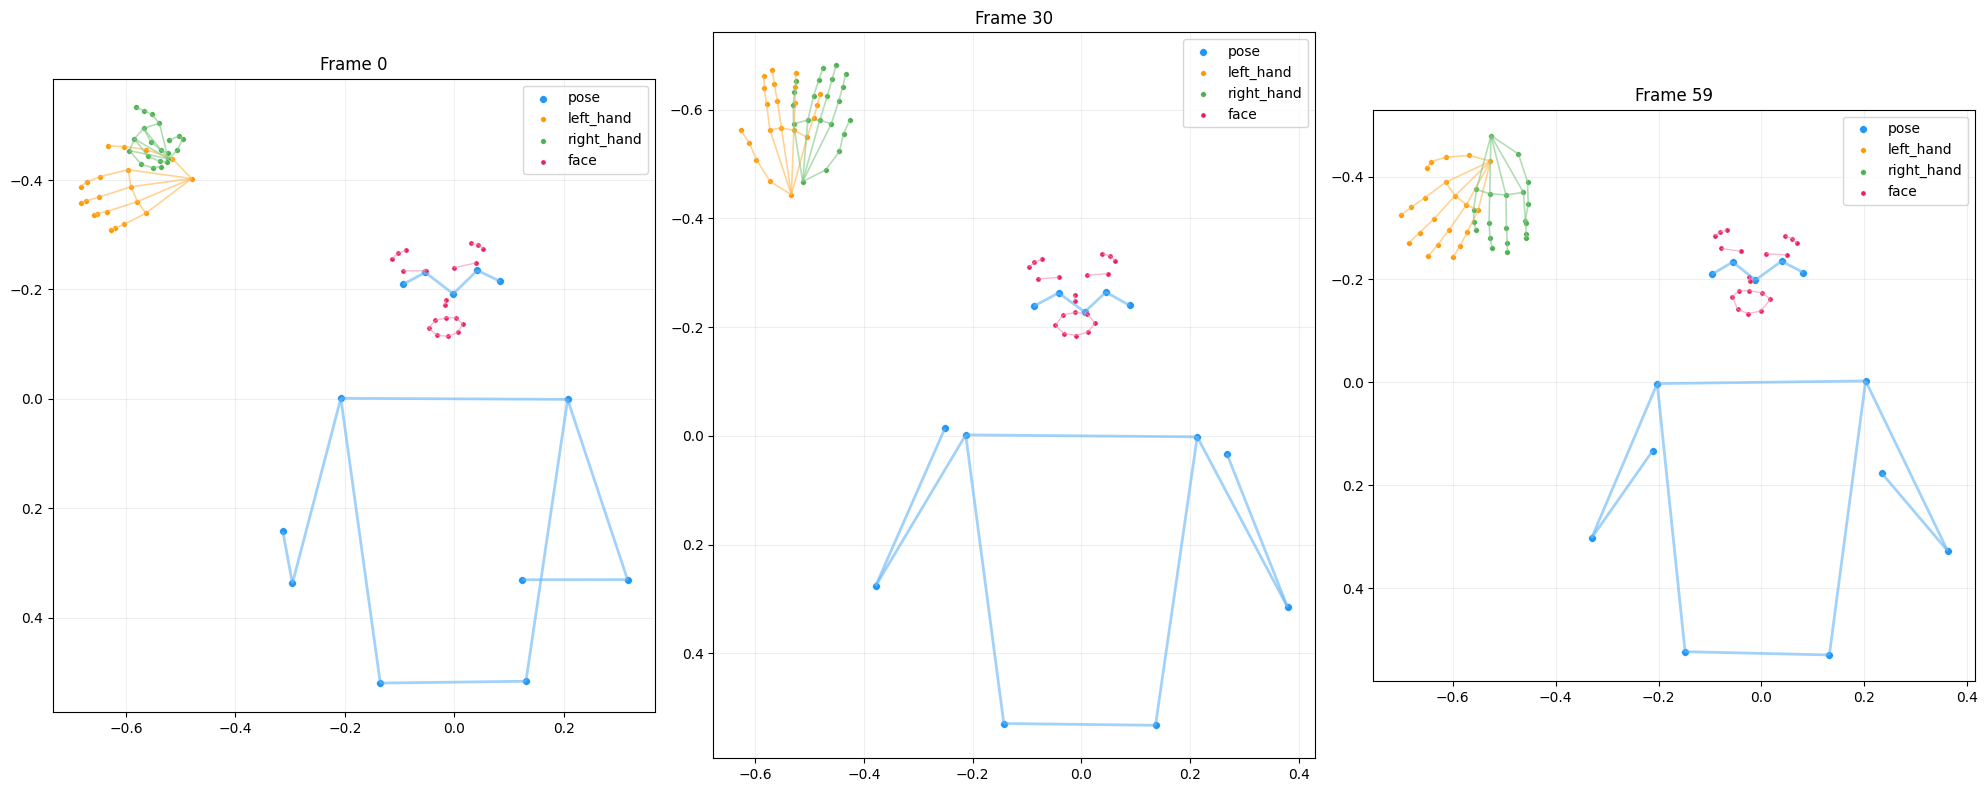

Saved: skeleton_plot.png


In [3]:
"""
Visualize 75 landmark skeletons from preprocessed data.

Supports:
    - (T, 225)  → flattened (75 joints × 3 coords)
    - (T, 75, 3)

Automatically detects coordinate format:
    - interleaved: [x1,y1,z1,x2,y2,z2,...]
    - grouped:     [x1..x75, y1..y75, z1..z75]
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from pathlib import Path
import sys

# ─── Landmark group sizes ───────────────────────────────────────────
P = 13   # pose
LH = 21  # left hand
RH = 21  # right hand
F = 20   # face

POSE_RANGE  = (0, P)
LHAND_RANGE = (P, P + LH)
RHAND_RANGE = (P + LH, P + LH + RH)
FACE_RANGE  = (P + LH + RH, P + LH + RH + F)

# ─── Skeleton connections ───────────────────────────────────────────

POSE_CONNS = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
]

def _hand_conns(offset):
    conns = []
    for base in [1, 5, 9, 13, 17]:
        conns.append((offset, offset + base))
    for start in [1, 5, 9, 13, 17]:
        for i in range(3):
            conns.append((offset + start + i, offset + start + i + 1))
    for a, b in [(5, 9), (9, 13), (13, 17)]:
        conns.append((offset + a, offset + b))
    return conns

LHAND_CONNS = _hand_conns(P)
RHAND_CONNS = _hand_conns(P + LH)

FO = P + LH + RH
FACE_CONNS = [
    (FO+0, FO+4), (FO+4, FO+2), (FO+2, FO+5), (FO+5, FO+1),
    (FO+0, FO+6), (FO+6, FO+3), (FO+3, FO+7), (FO+7, FO+1),
    (FO+8, FO+9), (FO+9, FO+10),
    (FO+11, FO+12), (FO+12, FO+13),
    (FO+14, FO+15),
    (FO+16, FO+17),
    (FO+18, FO+19),
]

# ─── Colors ─────────────────────────────────────────────────────────

COLORS = {
    "pose":       "#2196F3",
    "left_hand":  "#FF9800",
    "right_hand": "#4CAF50",
    "face":       "#E91E63",
}

CONN_COLORS = {
    "pose":       "#64B5F6",
    "left_hand":  "#FFB74D",
    "right_hand": "#81C784",
    "face":       "#F48FB1",
}

# ─── Shape Handling ─────────────────────────────────────────────────

def reshape_to_75x3(data):
    """
    Converts input to (T, 75, 3)
    """
    if data.ndim == 3 and data.shape[1:] == (75, 3):
        return data

    if data.ndim == 2 and data.shape[1] == 225:
        T = data.shape[0]

        # Try interleaved first
        reshaped = data.reshape(T, 75, 3)

        # Heuristic: if x/y look too constant → probably wrong format
        variance_xy = np.var(reshaped[:, :, :2])
        if variance_xy < 1e-6:
            # fallback to grouped format
            reshaped = data.reshape(T, 3, 75).transpose(0, 2, 1)

        return reshaped

    raise ValueError(f"Unsupported shape: {data.shape}")

# ─── Plotting ───────────────────────────────────────────────────────

def plot_skeleton(joints, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 8))
    else:
        fig = ax.figure

    xy = joints[:, :2]

    def draw(conns, color, lw):
        segments = []
        for i, j in conns:
            if np.allclose(xy[i], 0) or np.allclose(xy[j], 0):
                continue
            segments.append([xy[i], xy[j]])
        if segments:
            ax.add_collection(LineCollection(segments, colors=color, linewidths=lw, alpha=0.6))

    draw(POSE_CONNS, CONN_COLORS["pose"], 2.0)
    draw(LHAND_CONNS, CONN_COLORS["left_hand"], 1.2)
    draw(RHAND_CONNS, CONN_COLORS["right_hand"], 1.2)
    draw(FACE_CONNS, CONN_COLORS["face"], 1.0)

    groups = {
        "pose":       xy[POSE_RANGE[0]:POSE_RANGE[1]],
        "left_hand":  xy[LHAND_RANGE[0]:LHAND_RANGE[1]],
        "right_hand": xy[RHAND_RANGE[0]:RHAND_RANGE[1]],
        "face":       xy[FACE_RANGE[0]:FACE_RANGE[1]],
    }

    sizes = {"pose": 30, "left_hand": 16, "right_hand": 16, "face": 14}

    for name, pts in groups.items():
        mask = ~np.all(pts == 0, axis=1)
        if mask.any():
            ax.scatter(
                pts[mask, 0], pts[mask, 1],
                s=sizes[name], c=COLORS[name],
                label=name, edgecolors='white', linewidths=0.3
            )

    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.2)

    return fig, ax

# ─── Main ───────────────────────────────────────────────────────────

if __name__ == "__main__":

    npy_path = Path("data/01April_2010_Thursday_heute-6697.npy")

    raw = np.load(npy_path)
    print(f"Loaded: {npy_path.name} shape={raw.shape}")

    try:
        data = reshape_to_75x3(raw)
    except Exception as e:
        print(e)
        sys.exit(1)

    T = data.shape[0]
    flat = data.reshape(T, -1)

    print(f"Processed: {data.shape} → {flat.shape}")

    # Select frames
    norms = np.linalg.norm(flat, axis=1)
    nonzero = np.where(norms > 0)[0]

    if len(nonzero) == 0:
        frames = [0, T//2, T-1]
    else:
        frames = [nonzero[0], nonzero[len(nonzero)//2], nonzero[-1]]

    fig, axes = plt.subplots(1, 3, figsize=(20, 8))

    for ax, idx in zip(axes, frames):
        plot_skeleton(data[idx], title=f"Frame {idx}", ax=ax)

    plt.tight_layout()
    plt.savefig("skeleton_plot.png", dpi=150)
    plt.show()

    print("Saved: skeleton_plot.png")